# ADQUISICIÓN Y PREPROCESAMIENTO DE DATOS Y SEÑALES

## Exploración inicial (EDA)

### Carga del dataset y verificacion de clases

In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE = '/content/drive/MyDrive/PERCEPCION COMPUTACIONAL - LAB: 6013/GRUPO 1/Dataset/Potato_Dataset'

for clase in sorted(os.listdir(BASE)):
    ruta = os.path.join(BASE, clase)
    if os.path.isdir(ruta):
        print(f"{clase}: {len(os.listdir(ruta))} imagenes")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Blackspot Bruising Care: 770 imagenes
Dry Rot Care: 1355 imagenes
Healthy Potatoes: 815 imagenes
Soft Rot Care: 560 imagenes


### MUESTRAS

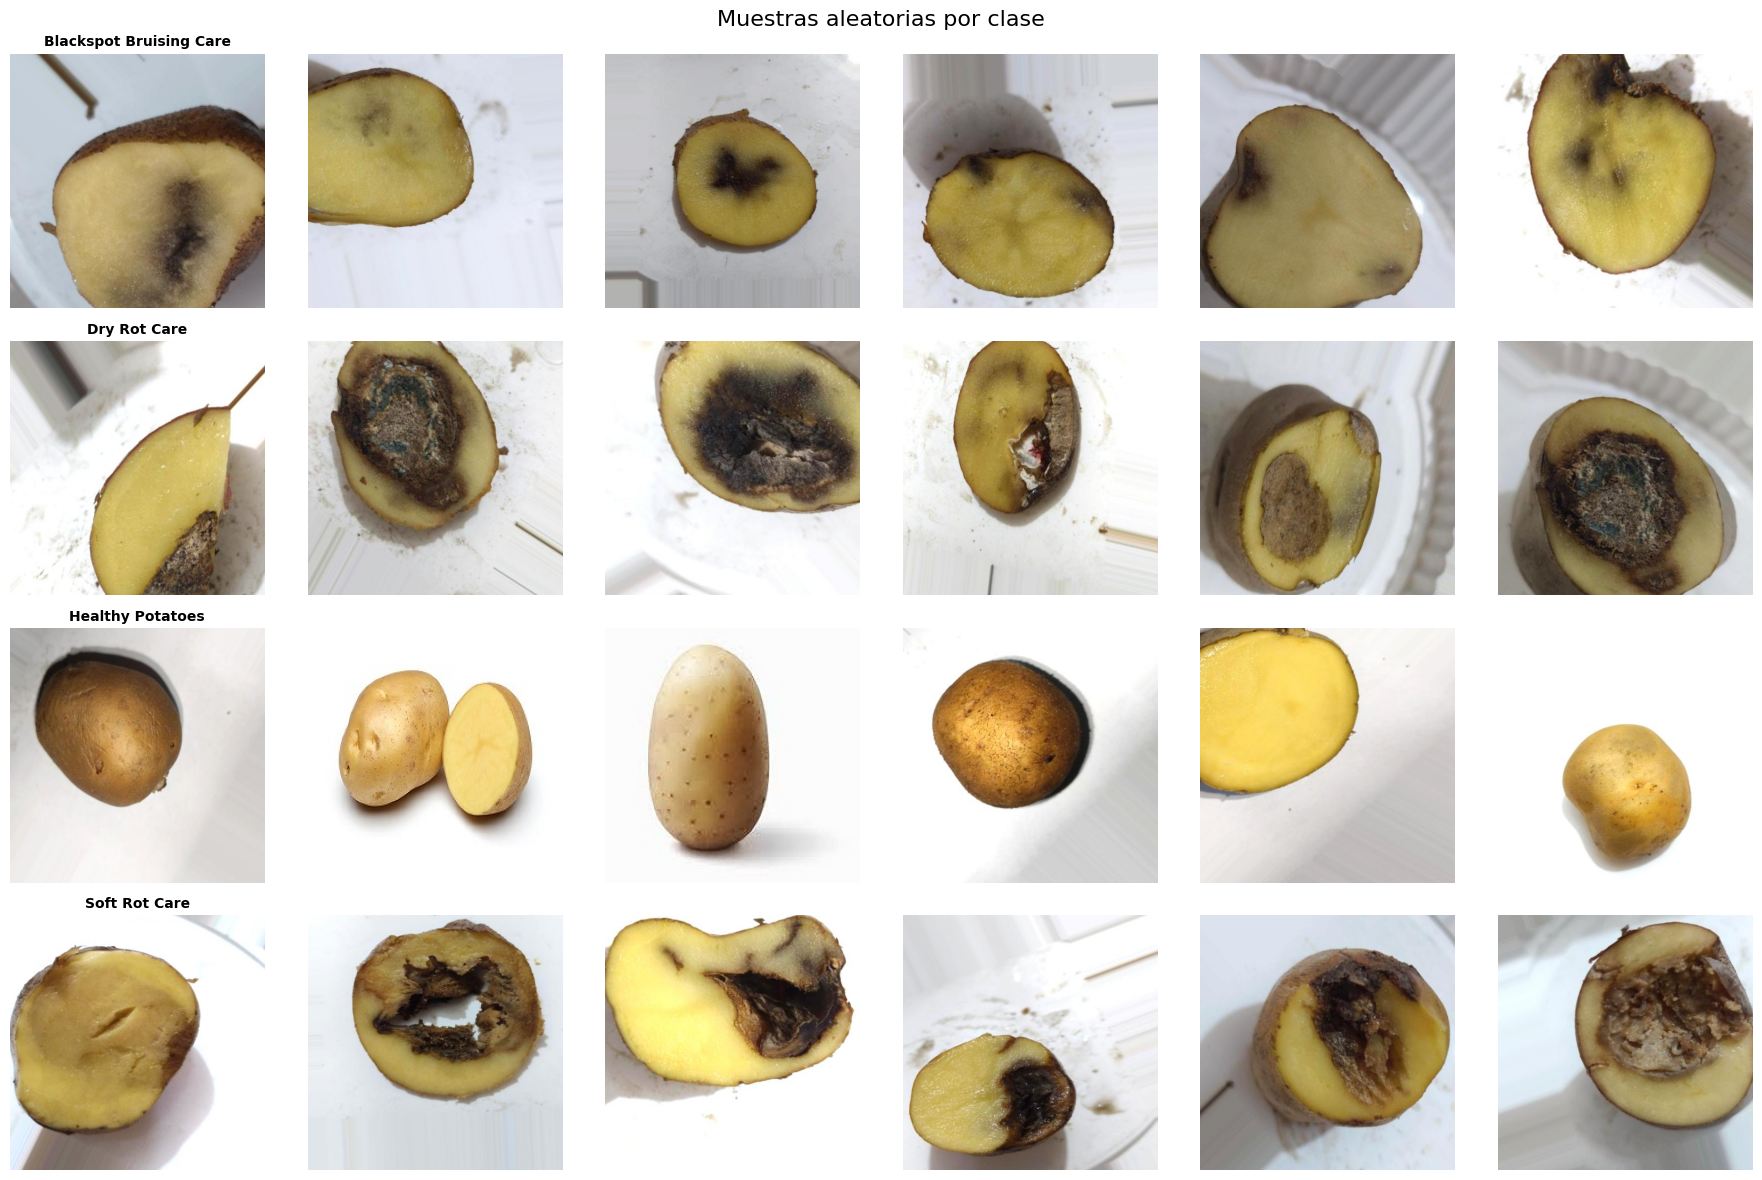

In [7]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt
from PIL import Image
import random

CLASES = sorted(os.listdir(BASE))
random.seed(42)

fig, axes = plt.subplots(4, 6, figsize=(18, 12))
fig.suptitle('Muestras aleatorias por clase', fontsize=16)

for i, clase in enumerate(CLASES):
    ruta_clase = os.path.join(BASE, clase)
    archivos = random.sample(os.listdir(ruta_clase), 6)
    for j, archivo in enumerate(archivos):
        img = Image.open(os.path.join(ruta_clase, archivo))
        axes[i][j].imshow(img)
        axes[i][j].axis('off')
        if j == 0:
            axes[i][j].set_title(clase, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('muestras_por_clase.png', dpi=1550, bbox_inches='tight')
plt.show()

### HISTOGRAMA DE INTENSIDAD 

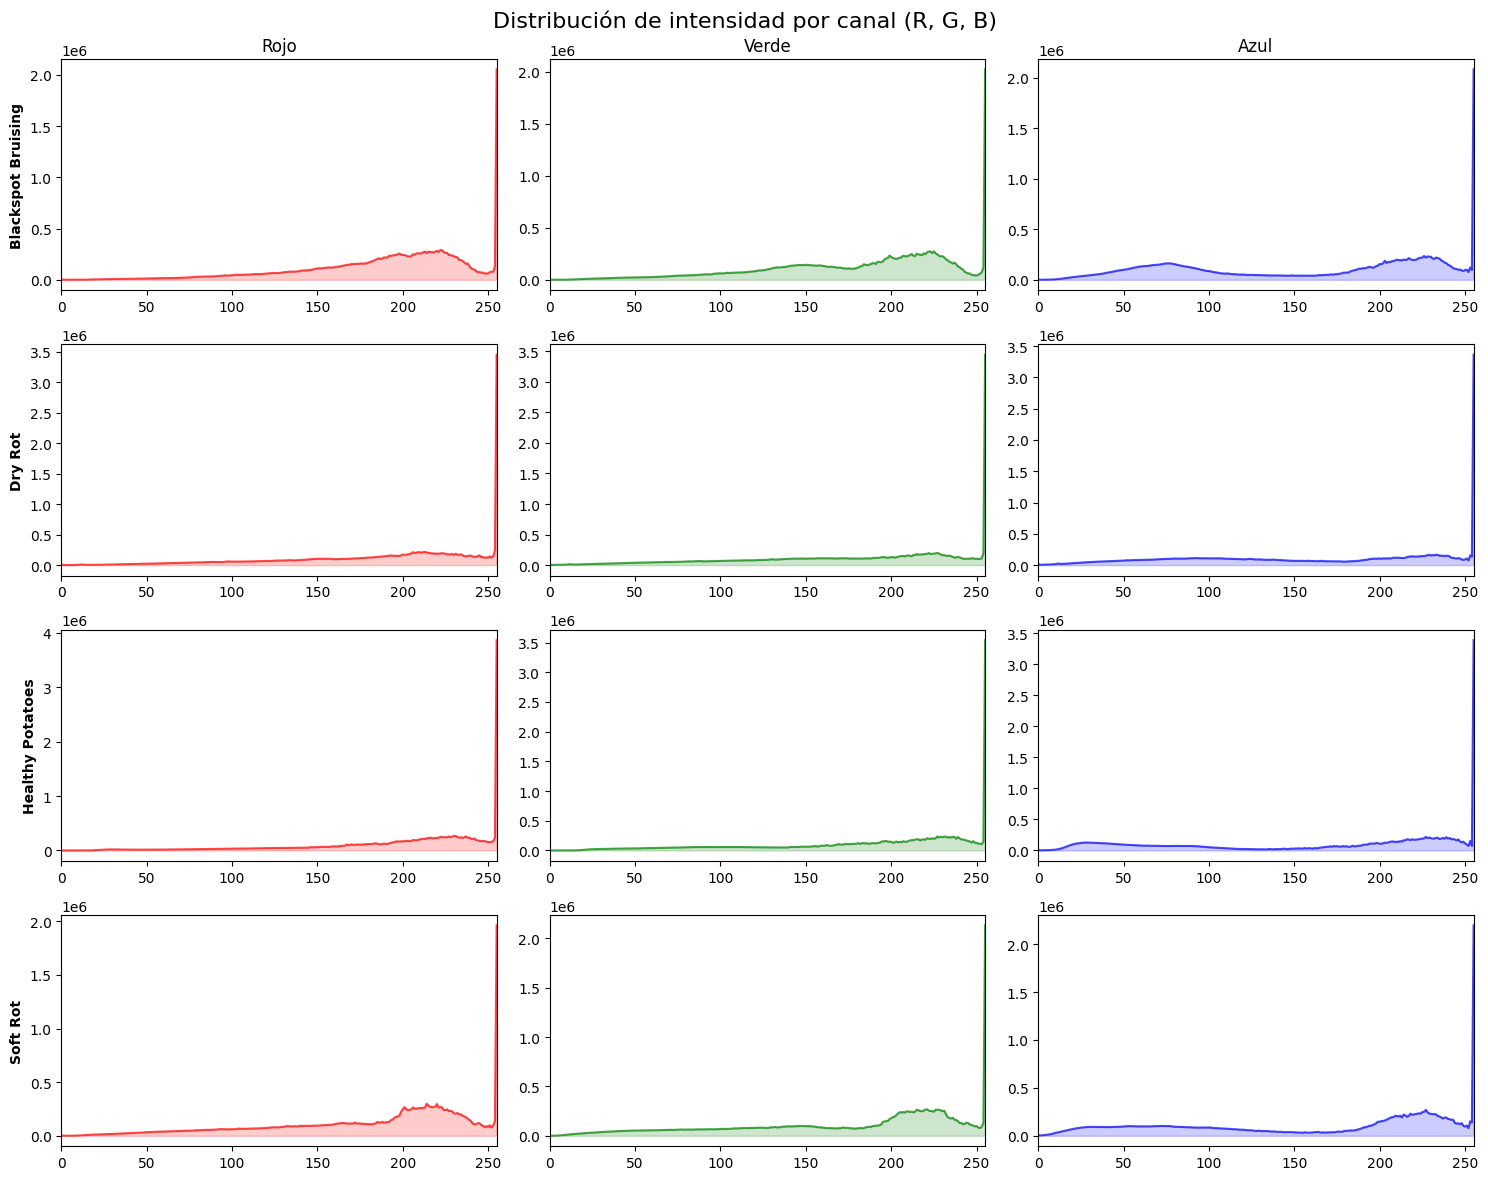

In [8]:
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
fig.suptitle('Distribución de intensidad por canal (R, G, B)', fontsize=16)
canales = ['Rojo', 'Verde', 'Azul']
colores = ['red', 'green', 'blue']

for i, clase in enumerate(CLASES):
    ruta_clase = os.path.join(BASE, clase)
    archivos = random.sample(os.listdir(ruta_clase), min(100, len(os.listdir(ruta_clase))))
    
    histogramas = {c: np.zeros(256) for c in range(3)}
    
    for archivo in archivos:
        img = cv2.imread(os.path.join(ruta_clase, archivo))
        if img is None:
            continue
        for c in range(3):
            hist = cv2.calcHist([img], [c], None, [256], [0, 256]).flatten()
            histogramas[c] += hist
    
    for j, (canal, color) in enumerate(zip(canales, colores)):
        c_idx = [2, 1, 0][j]  # BGR a RGB
        axes[i][j].plot(histogramas[c_idx], color=color, alpha=0.7)
        axes[i][j].fill_between(range(256), histogramas[c_idx], alpha=0.2, color=color)
        axes[i][j].set_xlim([0, 255])
        if i == 0:
            axes[i][j].set_title(canal, fontsize=12)
        if j == 0:
            axes[i][j].set_ylabel(clase.replace(' Care', ''), fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('histogramas_intensidad.png', dpi=150, bbox_inches='tight')
plt.show()

### ESTADISTICAS DE SEÑALES

In [9]:
print("=" * 70)
print(f"{'Clase':<25} {'Media R':>8} {'Media G':>8} {'Media B':>8} {'Std R':>7} {'Std G':>7} {'Std B':>7}")
print("=" * 70)

dimensiones = set()
corruptas = []

for clase in CLASES:
    ruta_clase = os.path.join(BASE, clase)
    archivos = os.listdir(ruta_clase)
    medias_r, medias_g, medias_b = [], [], []
    
    for archivo in archivos:
        img = cv2.imread(os.path.join(ruta_clase, archivo))
        if img is None:
            corruptas.append(f"{clase}/{archivo}")
            continue
        dimensiones.add(img.shape[:2])
        b, g, r = cv2.split(img)
        medias_r.append(r.mean())
        medias_g.append(g.mean())
        medias_b.append(b.mean())
    
    print(f"{clase:<25} {np.mean(medias_r):>8.1f} {np.mean(medias_g):>8.1f} {np.mean(medias_b):>8.1f} "
          f"{np.std(medias_r):>7.1f} {np.std(medias_g):>7.1f} {np.std(medias_b):>7.1f}")

print("=" * 70)
print(f"\nDimensiones encontradas: {dimensiones}")
print(f"Imágenes corruptas: {len(corruptas)}")
if corruptas:
    for c in corruptas:
        print(f"  - {c}")

Clase                      Media R  Media G  Media B   Std R   Std G   Std B
Blackspot Bruising Care      191.1    181.8    160.0    21.2    20.7    20.3
Dry Rot Care                 184.9    175.2    159.4    27.7    26.2    25.1
Healthy Potatoes             203.8    189.3    164.1    20.5    21.1    22.0
Soft Rot Care                183.7    176.9    162.3    21.8    21.0    20.3

Dimensiones encontradas: {(512, 512), (196, 257), (318, 238), (262, 327), (178, 283), (365, 548), (318, 224), (580, 1068), (224, 224), (319, 426), (472, 600), (320, 427), (365, 369), (365, 333), (327, 517), (318, 220), (447, 640), (360, 452)}
Imágenes corruptas: 0


### DETECCION DE ANOMALIAS

In [10]:
import hashlib

hashes = {}
duplicados = []

for clase in CLASES:
    ruta_clase = os.path.join(BASE, clase)
    for archivo in os.listdir(ruta_clase):
        filepath = os.path.join(ruta_clase, archivo)
        with open(filepath, 'rb') as f:
            h = hashlib.md5(f.read()).hexdigest()
        if h in hashes:
            duplicados.append((clase, archivo, hashes[h]))
        else:
            hashes[h] = f"{clase}/{archivo}"

print(f"Duplicados encontrados: {len(duplicados)}")
for d in duplicados[:10]:
    print(f"  {d[0]}/{d[1]}  ==  {d[2]}")

Duplicados encontrados: 0


## Partición de datos: entrenamiento, validación y prueba

In [11]:
from sklearn.model_selection import train_test_split
import shutil

SEED = 42
DEST = '/content/dataset_particionado'

# Recopilar rutas y etiquetas
rutas, etiquetas = [], []
for clase in CLASES:
    ruta_clase = os.path.join(BASE, clase)
    for archivo in os.listdir(ruta_clase):
        rutas.append(os.path.join(ruta_clase, archivo))
        etiquetas.append(clase)

# Partición estratificada
X_train, X_temp, y_train, y_temp = train_test_split(
    rutas, etiquetas, test_size=0.30, stratify=etiquetas, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

# Copiar a carpetas
for split, X, y in [('train', X_train, y_train), ('val', X_val, y_val), ('test', X_test, y_test)]:
    for ruta, clase in zip(X, y):
        destino = os.path.join(DEST, split, clase)
        os.makedirs(destino, exist_ok=True)
        shutil.copy2(ruta, destino)

# Verificar conteos
print(f"{'Clase':<30} {'Train':>6} {'Val':>6} {'Test':>6} {'Total':>6}")
print("=" * 55)
for clase in CLASES:
    tr = len(os.listdir(os.path.join(DEST, 'train', clase)))
    va = len(os.listdir(os.path.join(DEST, 'val', clase)))
    te = len(os.listdir(os.path.join(DEST, 'test', clase)))
    print(f"{clase:<30} {tr:>6} {va:>6} {te:>6} {tr+va+te:>6}")

Clase                           Train    Val   Test  Total
Blackspot Bruising Care           539    115    116    770
Dry Rot Care                      948    204    203   1355
Healthy Potatoes                  571    122    122    815
Soft Rot Care                     392     84     84    560
